In [32]:
"""
RG-OTM: Robust Graph-Aware Online Trichromatic Matcher
A comprehensive pipeline for evaluating matching algorithms
"""

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
from enum import Enum
import time
from collections import defaultdict
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [33]:
# ==================== DATA STRUCTURES ====================

class VertexType(Enum):
    LEFT_ONLINE = "left_online"
    RIGHT_ONLINE = "right_online"
    OFFLINE = "offline"

@dataclass
class Vertex:
    id: int
    type: VertexType
    features: Optional[np.ndarray] = None
    arrival_time: Optional[int] = None

@dataclass
class Edge:
    u: Vertex
    v: Vertex
    weight: float = 1.0
    features: Optional[np.ndarray] = None

@dataclass
class TripartiteGraph:
    left_vertices: List[Vertex]
    right_vertices: List[Vertex]
    offline_vertices: List[Vertex]
    edges_left: List[Edge]
    edges_right: List[Edge]

    def get_vertex_by_id(self, vertex_id: int) -> Optional[Vertex]:
        """Find vertex by ID across all partitions"""
        for v in self.left_vertices + self.right_vertices + self.offline_vertices:
            if v.id == vertex_id:
                return v
        return None

    def get_neighbors(self, vertex: Vertex) -> List[Vertex]:
        """Get neighbors of a vertex"""
        neighbors = []
        if vertex.type == VertexType.LEFT_ONLINE:
            neighbors = [e.v for e in self.edges_left if e.u.id == vertex.id]
        elif vertex.type == VertexType.RIGHT_ONLINE:
            neighbors = [e.v for e in self.edges_right if e.u.id == vertex.id]
        elif vertex.type == VertexType.OFFLINE:
            left_neighbors = [e.u for e in self.edges_left if e.v.id == vertex.id]
            right_neighbors = [e.u for e in self.edges_right if e.v.id == vertex.id]
            neighbors = left_neighbors + right_neighbors
        return neighbors

In [34]:
# ==================== ALGORITHMS ====================

class GreedyAlgorithm:
    """Simple greedy matching algorithm"""

    def __init__(self, name="Greedy"):
        self.name = name
        self.matched_triplets = []
        self.matched_vertices = set()

    def reset(self):
        self.matched_triplets = []
        self.matched_vertices = set()

    def match(self, graph: TripartiteGraph, arrival_sequence: List[Vertex]) -> List[Tuple]:
        """Perform greedy matching"""
        self.reset()

        for vertex in arrival_sequence:
            if vertex.id in self.matched_vertices:
                continue

            # Find available neighbors
            neighbors = graph.get_neighbors(vertex)
            available_neighbors = [n for n in neighbors if n.id not in self.matched_vertices]

            if not available_neighbors:
                continue

            # For online vertices, we need to find triplets
            if vertex.type in [VertexType.LEFT_ONLINE, VertexType.RIGHT_ONLINE]:
                # Try to form a triplet
                for neighbor in available_neighbors:
                    if neighbor.type != VertexType.OFFLINE:
                        continue

                    # Find a vertex from the opposite side connected to the same offline
                    opposite_type = (VertexType.RIGHT_ONLINE if vertex.type == VertexType.LEFT_ONLINE else VertexType.LEFT_ONLINE)

                    # Get all vertices connected to this offline neighbor
                    all_connected = graph.get_neighbors(neighbor)
                    potential_partners = [v for v in all_connected
                                        if v.type == opposite_type
                                        and v.id not in self.matched_vertices]

                    if potential_partners:
                        # Pick the first available partner
                        partner = potential_partners[0]
                        triplet = (vertex, neighbor, partner)
                        self.matched_triplets.append(triplet)
                        self.matched_vertices.update([v.id for v in triplet])
                        break

        return self.matched_triplets

class EpsilonRankingAlgorithm:
    """ε-RANKING algorithm for trichromatic matching"""

    def __init__(self, epsilon=0.5, name="ε-RANKING"):
        self.name = name
        self.epsilon = epsilon
        self.matched_triplets = []
        self.matched_vertices = set()
        self.offline_ranks = {}

    def reset(self):
        self.matched_triplets = []
        self.matched_vertices = set()
        self.offline_ranks = {}

    def assign_ranks(self, offline_vertices: List[Vertex]):
        """Assign random ranks to offline vertices"""
        for v in offline_vertices:
            self.offline_ranks[v.id] = np.random.random()

    def match(self, graph: TripartiteGraph, arrival_sequence: List[Vertex]) -> List[Tuple]:
        """Perform ε-RANKING matching"""
        self.reset()
        self.assign_ranks(graph.offline_vertices)

        # Store waiting pairs (online vertex, offline vertex)
        waiting_pairs = []

        for vertex in arrival_sequence:
            if vertex.id in self.matched_vertices:
                continue

            # Get available offline neighbors
            neighbors = graph.get_neighbors(vertex)
            offline_neighbors = [n for n in neighbors if n.type == VertexType.OFFLINE and n.id not in self.matched_vertices]

            if not offline_neighbors:
                continue

            # Sort by rank
            offline_neighbors.sort(key=lambda x: self.offline_ranks[x.id])

            if vertex.type == VertexType.LEFT_ONLINE:
                # Add to waiting pairs
                for neighbor in offline_neighbors:
                    waiting_pairs.append((vertex, neighbor))

            elif vertex.type == VertexType.RIGHT_ONLINE:
                # Try to match with waiting pairs
                for neighbor in offline_neighbors:
                    # Find waiting left vertices connected to this offline
                    matching_pairs = [(left, off) for left, off in waiting_pairs
                                    if off.id == neighbor.id]

                    if matching_pairs:
                        # Pick the first matching pair
                        left_vertex, offline_vertex = matching_pairs[0]
                        triplet = (left_vertex, offline_vertex, vertex)
                        self.matched_triplets.append(triplet)
                        self.matched_vertices.update([v.id for v in triplet])

                        # Remove from waiting pairs
                        waiting_pairs = [p for p in waiting_pairs if p[0].id != left_vertex.id]
                        break

        return self.matched_triplets

In [35]:
# ==================== GRAPH GENERATORS ====================

class GraphGenerator:
    """Generate synthetic and real-world tripartite graphs"""

    @staticmethod
    def generate_random_partition_graph(n_left: int, n_right: int, n_offline: int, density: float = 0.3, 
                                        weight_range: Tuple[float, float] = (0.5, 1.0),
                                        seed: int = 42) -> TripartiteGraph:
        """Generate a random partition graph"""
        np.random.seed(seed)

        # Create vertices
        left_vertices = [Vertex(i, VertexType.LEFT_ONLINE)
                        for i in range(n_left)]
        right_vertices = [Vertex(i + n_left, VertexType.RIGHT_ONLINE) for i in range(n_right)]
        offline_vertices = [Vertex(i + n_left + n_right, VertexType.OFFLINE) for i in range(n_offline)]

        # Create edges based on density
        edges_left = []
        edges_right = []

        # Left to offline edges
        for left in left_vertices:
            for offline in offline_vertices:
                if np.random.random() < density:
                    weight = np.random.uniform(*weight_range)
                    edges_left.append(Edge(left, offline, weight))

        # Right to offline edges
        for right in right_vertices:
            for offline in offline_vertices:
                if np.random.random() < density:
                    weight = np.random.uniform(*weight_range)
                    edges_right.append(Edge(right, offline, weight))

        return TripartiteGraph(left_vertices, right_vertices, offline_vertices, edges_left, edges_right)

    @staticmethod
    def generate_nws_graph(n_left: int, n_right: int, n_offline: int, k: int = 4, p: float = 0.3,
                            weight_range: Tuple[float, float] = (0.5, 1.0),
                            seed: int = 42) -> TripartiteGraph:
        """Generate a Newman-Watts-Strogatz small-world graph"""
        np.random.seed(seed)

        # Create vertices
        left_vertices = [Vertex(i, VertexType.LEFT_ONLINE)
                        for i in range(n_left)]
        right_vertices = [Vertex(i + n_left, VertexType.RIGHT_ONLINE)
                            for i in range(n_right)]
        offline_vertices = [Vertex(i + n_left + n_right, VertexType.OFFLINE)
                            for i in range(n_offline)]

        edges_left = []
        edges_right = []

        # Create a small-world structure for left-offline connections
        # Each left vertex connects to k nearest offline vertices
        for i, left in enumerate(left_vertices):
            for j in range(k):
                offline_idx = (i + j) % n_offline
                weight = np.random.uniform(*weight_range)
                edges_left.append(Edge(left, offline_vertices[offline_idx], weight))

            # Add random edges with probability p
            for offline in offline_vertices:
                if np.random.random() < p:
                    weight = np.random.uniform(*weight_range)
                    edges_left.append(Edge(left, offline, weight))

        # Similar for right-offline connections
        for i, right in enumerate(right_vertices):
            for j in range(k):
                offline_idx = (i + j) % n_offline
                weight = np.random.uniform(*weight_range)
                edges_right.append(Edge(right, offline_vertices[offline_idx], weight))

            for offline in offline_vertices:
                if np.random.random() < p:
                    weight = np.random.uniform(*weight_range)
                    edges_right.append(Edge(right, offline, weight))

        return TripartiteGraph(left_vertices, right_vertices, offline_vertices,
                                edges_left, edges_right)

    @staticmethod
    def load_real_dataset(dataset_name: str) -> Optional[TripartiteGraph]:
        """Load a real-world dataset"""

        print(f"Loading {dataset_name} dataset...")

        if dataset_name == "IAU_Constellations":
            
            ds = pd.read_csv("./Dataset/constellation.csv")
            
            # Create vertices
            left_vertices = [Vertex(i, VertexType.LEFT_ONLINE) for i in ds["NASA"]]
            right_vertices = [Vertex(i + len(left_vertices), VertexType.RIGHT_ONLINE) for i in ds["IAU"]]
            offline_vertices = [Vertex(i + len(left_vertices) + len(right_vertices), VertexType.OFFLINE) for i in ds["Origin"]]

            # Create edges
            edges_left = []
            edges_right = []
            for _, row in ds.iterrows():
                left_vertex = next(v for v in left_vertices if v.id == row["NASA"])
                right_vertex = next(v for v in right_vertices if v.id == row["IAU"] + len(left_vertices))
                offline_vertex = next(v for v in offline_vertices if v.id == row["Origin"] + len(left_vertices) + len(right_vertices))

                edges_left.append(Edge(left_vertex, offline_vertex))
                edges_right.append(Edge(right_vertex, offline_vertex))

            return TripartiteGraph(left_vertices, right_vertices, offline_vertices,
                                    edges_left, edges_right)

        elif dataset_name == "DS_Job_Salaries":
            
            ds = pd.read_csv("./Dataset/constellation.csv")
            
            # Create vertices
            left_vertices = [Vertex(i, VertexType.LEFT_ONLINE) for i in ds["salary_currency"]]
            right_vertices = [Vertex(i + len(left_vertices), VertexType.RIGHT_ONLINE) for i in ds["employee_residence"]]
            offline_vertices = [Vertex(i + len(left_vertices) + len(right_vertices), VertexType.OFFLINE) for i in ds["job_title"]]

            # Create edges
            edges_left = []
            edges_right = []
            for _, row in ds.iterrows():
                left_vertex = next(v for v in left_vertices if v.id == row["salary_currency"])
                right_vertex = next(v for v in right_vertices if v.id == row["employee_residence"] + len(left_vertices))
                offline_vertex = next(v for v in offline_vertices if v.id == row["job_title"] + len(left_vertices) + len(right_vertices))

                edges_left.append(Edge(left_vertex, offline_vertex))
                edges_right.append(Edge(right_vertex, offline_vertex))

        else:
            print(f"Dataset {dataset_name} not found")
            return None

In [36]:
# ==================== VISUALIZATION ====================

class GraphVisualizer:
    """Visualize tripartite graphs and matching results"""

    @staticmethod
    def plot_network(graph: TripartiteGraph,
                    matched_triplets: List[Tuple] = None,
                    title: str = "Tripartite Graph",
                    figsize: Tuple[int, int] = (12, 8)):
        """Static visualization of the graph"""
        fig, ax = plt.subplots(figsize=figsize)

        # Position vertices in three columns
        pos = {}

        # Left vertices
        for i, v in enumerate(graph.left_vertices):
            pos[v.id] = (0, i / max(len(graph.left_vertices), 1))

        # Offline vertices
        for i, v in enumerate(graph.offline_vertices):
            pos[v.id] = (1, i / max(len(graph.offline_vertices), 1))

        # Right vertices
        for i, v in enumerate(graph.right_vertices):
            pos[v.id] = (2, i / max(len(graph.right_vertices), 1))

        # Draw edges
        for edge in graph.edges_left + graph.edges_right:
            x = [pos[edge.u.id][0], pos[edge.v.id][0]]
            y = [pos[edge.u.id][1], pos[edge.v.id][1]]
            ax.plot(x, y, 'gray', alpha=0.3, linewidth=0.5)

        # Draw vertices
        for v_list, color, label in [
            (graph.left_vertices, 'blue', 'Left Online'),
            (graph.offline_vertices, 'green', 'Offline'),
            (graph.right_vertices, 'red', 'Right Online')
        ]:
            x = [pos[v.id][0] for v in v_list]
            y = [pos[v.id][1] for v in v_list]
            ax.scatter(x, y, c=color, s=100, label=label, alpha=0.7)

        # Highlight matched triplets
        if matched_triplets:
            for triplet in matched_triplets:
                left, offline, right = triplet
                # Draw triangle for matched triplet
                triangle_x = [pos[left.id][0], pos[offline.id][0], pos[right.id][0], pos[left.id][0]]
                triangle_y = [pos[left.id][1], pos[offline.id][1], pos[right.id][1], pos[left.id][1]]
                ax.plot(triangle_x, triangle_y, 'orange', linewidth=2, alpha=0.8)
                ax.fill(triangle_x, triangle_y, 'orange', alpha=0.2)

        ax.set_xlim(-0.5, 2.5)
        ax.set_ylim(-0.1, 1.1)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

        return fig

    @staticmethod
    def plot_competitive_ratio(results: Dict[str, List[float]],
                                title: str = "Competitive Ratio Over Iterations"):
        """Plot competitive ratio over iterations"""
        fig, ax = plt.subplots(figsize=(10, 6))

        for algo_name, ratios in results.items():
            iterations = list(range(1, len(ratios) + 1))
            ax.plot(iterations, ratios, label=algo_name, linewidth=2)

        ax.set_xlabel("Iteration")
        ax.set_ylabel("Competitive Ratio")
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

        return fig

    @staticmethod
    def plot_density_vs_performance(density_results: Dict[str, Dict[float, float]],
                                    title: str = "Competitive Ratio vs Graph Density"):
        """Plot competitive ratio vs graph density"""
        fig, ax = plt.subplots(figsize=(10, 6))

        for algo_name, results in density_results.items():
            densities = list(results.keys())
            ratios = list(results.values())

            # Sort by density
            sorted_data = sorted(zip(densities, ratios))
            densities = [d for d, _ in sorted_data]
            ratios = [r for _, r in sorted_data]

            ax.plot(densities, ratios, 'o-', label=algo_name, linewidth=2)

        ax.set_xlabel("Graph Density")
        ax.set_ylabel("Average Competitive Ratio")
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

        return fig

In [37]:
# ==================== EXPERIMENT RUNNER ====================

class ExperimentRunner:
    """Run comprehensive experiments comparing algorithms"""

    def __init__(self):
        self.results = {}
        self.visualizer = GraphVisualizer()

    def compute_optimal_matching(self, graph: TripartiteGraph) -> int:
        """Compute optimal offline matching size (approximation)"""
        # Create a bipartite graph for maximum matching
        B = nx.Graph()

        # Add edges from left to offline
        for edge in graph.edges_left:
            B.add_edge(edge.u.id, edge.v.id)

        # Add edges from right to offline
        for edge in graph.edges_right:
            B.add_edge(edge.u.id, edge.v.id)

        # Compute maximum matching
        matching = nx.algorithms.matching.max_weight_matching(B, maxcardinality=True)
        return len(matching) // 2  # Each match is counted twice

    def run_single_experiment(self, graph: TripartiteGraph,
                             algorithms: List, n_iterations: int = 10) -> Dict:
        """Run experiment on a single graph"""
        results = {algo.name: [] for algo in algorithms}

        for iteration in range(n_iterations):
            # Generate random arrival sequence
            arrival_sequence = graph.left_vertices + graph.right_vertices
            np.random.shuffle(arrival_sequence)

            for algorithm in algorithms:
                algorithm.reset()
                matched = algorithm.match(graph, arrival_sequence)

                # Compute competitive ratio
                optimal = self.compute_optimal_matching(graph)
                ratio = len(matched) / optimal if optimal > 0 else 0
                results[algorithm.name].append(ratio)

        # Compute averages
        avg_results = {algo: np.mean(ratios) for algo, ratios in results.items()}
        std_results = {algo: np.std(ratios) for algo, ratios in results.items()}

        return {
            'raw': results,
            'average': avg_results,
            'std': std_results
        }

    def run_density_experiment(self, n_left: int = 20, n_right: int = 20,
                              n_offline: int = 15, n_trials: int = 5):
        """Experiment with varying graph densities"""
        densities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
        algorithms = [
            GreedyAlgorithm(),
            EpsilonRankingAlgorithm(),
            RGOTMAlgorithm(rho=0.8, use_rl=True)
        ]

        density_results = {algo.name: {} for algo in algorithms}

        for density in tqdm(densities, desc="Testing densities"):
            trial_results = {algo.name: [] for algo in algorithms}

            for trial in range(n_trials):
                graph = GraphGenerator.generate_random_partition_graph(
                    n_left, n_right, n_offline, density=density)

                arrival = graph.left_vertices + graph.right_vertices
                np.random.shuffle(arrival)

                for algorithm in algorithms:
                    algorithm.reset()
                    matched = algorithm.match(graph, arrival)

                    optimal = self.compute_optimal_matching(graph)
                    ratio = len(matched) / optimal if optimal > 0 else 0
                    trial_results[algorithm.name].append(ratio)

            # Average over trials
            for algo_name in trial_results:
                density_results[algo_name][density] = np.mean(trial_results[algo_name])

        return density_results

    def run_iteration_experiment(self, dataset_name: str, n_iterations: int = 50):
        """Experiment over multiple iterations on real dataset"""
        # Load or generate dataset
        if dataset_name.startswith("synthetic"):
            graph = GraphGenerator.generate_random_partition_graph(
                30, 30, 20, density=0.4)
        else:
            graph = GraphGenerator.load_real_dataset(dataset_name)

        if graph is None:
            print(f"Could not load dataset: {dataset_name}")
            return None

        algorithms = [
            GreedyAlgorithm(),
            EpsilonRankingAlgorithm(epsilon=0.5),
            RGOTMAlgorithm(rho=0.8, use_rl=True)
        ]

        results = {algo.name: [] for algo in algorithms}

        for iteration in tqdm(range(n_iterations), desc=f"Testing on {dataset_name}"):
            arrival = graph.left_vertices + graph.right_vertices
            np.random.shuffle(arrival)

            for algorithm in algorithms:
                algorithm.reset()
                matched = algorithm.match(graph, arrival)

                optimal = self.compute_optimal_matching(graph)
                ratio = len(matched) / optimal if optimal > 0 else 0
                results[algorithm.name].append(ratio)

        return results

    def visualize_comparison(self, results: Dict[str, List[float]],
                           title: str = "Algorithm Comparison"):
        """Create comprehensive visualization"""
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=("Competitive Ratio Over Iterations",
                          "Average Performance",
                          "Performance Distribution",
                          "Cumulative Performance"),
            specs=[[{"type": "scatter"}, {"type": "bar"}],
                   [{"type": "box"}, {"type": "scatter"}]]
        )

        # 1. Line plot over iterations
        for algo_name, ratios in results.items():
            iterations = list(range(1, len(ratios) + 1))
            fig.add_trace(
                go.Scatter(x=iterations, y=ratios, name=algo_name, mode='lines+markers'),
                row=1, col=1
            )

        # 2. Bar plot of averages
        averages = {algo: np.mean(ratios) for algo, ratios in results.items()}
        fig.add_trace(
            go.Bar(x=list(averages.keys()), y=list(averages.values())),
            row=1, col=2
        )

        # 3. Box plot of distributions
        for algo_name, ratios in results.items():
            fig.add_trace(
                go.Box(y=ratios, name=algo_name, boxpoints='all'),
                row=2, col=1
            )

        # 4. Cumulative performance
        for algo_name, ratios in results.items():
            cumulative = np.cumsum(ratios)
            iterations = list(range(1, len(ratios) + 1))
            fig.add_trace(
                go.Scatter(x=iterations, y=cumulative, name=algo_name, mode='lines'),
                row=2, col=2
            )

        fig.update_layout(height=800, width=1200, title_text=title, showlegend=True)
        fig.update_xaxes(title_text="Iteration", row=1, col=1)
        fig.update_xaxes(title_text="Algorithm", row=1, col=2)
        fig.update_xaxes(title_text="Algorithm", row=2, col=1)
        fig.update_xaxes(title_text="Iteration", row=2, col=2)

        fig.update_yaxes(title_text="Competitive Ratio", row=1, col=1)
        fig.update_yaxes(title_text="Average Ratio", row=1, col=2)
        fig.update_yaxes(title_text="Ratio Distribution", row=2, col=1)
        fig.update_yaxes(title_text="Cumulative Ratio", row=2, col=2)

        return fig

In [38]:
# ==================== MAIN EXECUTION ====================

def run_comprehensive_experiment():
    """Run the complete experimental pipeline"""
    print("=" * 60)
    print("RG-OTM: Robust Online Trichromatic Matching Pipeline")
    print("=" * 60)

    runner = ExperimentRunner()

    # 1. Generate sample graph for visualization
    print("\n1. Generating sample graph...")
    sample_graph = GraphGenerator.generate_random_partition_graph(
        n_left=10, n_right=10, n_offline=8, density=0.4)

    # 2. Test algorithms on sample graph
    print("\n2. Testing algorithms on sample graph...")
    algorithms = [
        GreedyAlgorithm(),
        EpsilonRankingAlgorithm(epsilon=0.5),
        RGOTMAlgorithm(rho=0.8, use_rl=True)
    ]

    arrival_sequence = sample_graph.left_vertices + sample_graph.right_vertices
    np.random.shuffle(arrival_sequence)

    algorithm_results = {}
    for algorithm in algorithms:
        algorithm.reset()
        matched = algorithm.match(sample_graph, arrival_sequence)
        algorithm_results[algorithm.name] = {
            'matched': matched,
            'count': len(matched)
        }
        print(f"  {algorithm.name}: {len(matched)} triplets matched")

    # 3. Visualize the graph with matching
    print("\n3. Creating visualizations...")
    visualizer = GraphVisualizer()

    # Static visualization
    fig_static = visualizer.plot_network(
        sample_graph,
        matched_triplets=algorithm_results['RG-OTM']['matched'],
        title="Sample Tripartite Graph with RG-OTM Matching"
    )
    plt.show()

    # 4. Run density experiment
    print("\n4. Running density experiment...")
    density_results = runner.run_density_experiment(
        n_left=20, n_right=20, n_offline=15, n_trials=3)

    fig_density = visualizer.plot_density_vs_performance(
        density_results,
        title="Competitive Ratio vs Graph Density (Random Partition Graph)"
    )
    plt.show()

    # 5. Run iteration experiment
    print("\n5. Running iteration experiment...")
    iteration_results = runner.run_iteration_experiment(
        "synthetic_random", n_iterations=30)

    fig_iteration = visualizer.plot_competitive_ratio(
        iteration_results,
        title="Competitive Ratio Over Iterations"
    )
    plt.show()

    # 6. Create interactive comparison
    print("\n6. Creating interactive comparison...")
    fig_interactive = runner.visualize_comparison(
        iteration_results,
        title="Algorithm Performance Comparison"
    )

    # 7. Summary statistics
    print("\n7. Summary of results:")
    print("-" * 40)

    for algo_name, ratios in iteration_results.items():
        avg = np.mean(ratios)
        std = np.std(ratios)
        print(f"{algo_name}:")
        print(f"  Average Competitive Ratio: {avg:.4f}")
        print(f"  Standard Deviation: {std:.4f}")
        print(f"  Min/Max: {min(ratios):.4f}/{max(ratios):.4f}")
        print()

    # 8. Additional analysis: RL vs No-RL comparison
    print("8. Comparing RG-OTM with and without RL...")
    rg_otm_rl = RGOTMAlgorithm(rho=0.8, use_rl=True)
    rg_otm_no_rl = RGOTMAlgorithm(rho=0.8, use_rl=False)

    rl_results = {'With RL': [], 'Without RL': []}

    for _ in range(20):
        arrival = sample_graph.left_vertices + sample_graph.right_vertices
        np.random.shuffle(arrival)

        rg_otm_rl.reset()
        matched_rl = rg_otm_rl.match(sample_graph, arrival)

        rg_otm_no_rl.reset()
        matched_no_rl = rg_otm_no_rl.match(sample_graph, arrival)

        optimal = runner.compute_optimal_matching(sample_graph)

        rl_results['With RL'].append(len(matched_rl) / optimal)
        rl_results['Without RL'].append(len(matched_no_rl) / optimal)

    # Plot RL comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(rl_results['With RL']))
    width = 0.35

    ax.bar(x - width/2, rl_results['With RL'], width, label='With RL', alpha=0.8)
    ax.bar(x + width/2, rl_results['Without RL'], width, label='Without RL', alpha=0.8)

    ax.set_xlabel('Trial')
    ax.set_ylabel('Competitive Ratio')
    ax.set_title('Impact of RL on RG-OTM Performance')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('rl_comparison.png', dpi=300)
    plt.show()

    print("\nExperiment completed successfully!")

    return {
        'density_results': density_results,
        'iteration_results': iteration_results,
        'rl_comparison': rl_results
    }

In [39]:
# ==================== BENCHMARKING ====================

def benchmark_algorithms():
    """Benchmark all algorithms on various graph types"""
    print("\n🚀 Benchmarking Algorithms...")
    print("=" * 60)

    graph_types = [
        ("Random Partition", "random", 0.3),
        ("Small World", "nws", 0.3),
        ("Dense", "random", 0.7),
        ("Sparse", "random", 0.1)
    ]

    algorithms = [
        GreedyAlgorithm(),
        EpsilonRankingAlgorithm(epsilon=0.5),
        RGOTMAlgorithm(rho=0.8, use_rl=True),
        AdvancedRGOTM(rho=0.8, use_attention=True)
    ]

    results_table = []

    for graph_name, graph_type, density in graph_types:
        print(f"\n📈 Testing on {graph_name} graph (density: {density})...")

        # Generate graph
        if graph_type == "random":
            graph = GraphGenerator.generate_random_partition_graph(
                25, 25, 15, density=density)
        else:
            graph = GraphGenerator.generate_nws_graph(
                25, 25, 15, k=3, p=density/2)

        # Run each algorithm
        row = [graph_name]
        for algorithm in algorithms:
            algorithm.reset()

            # Run multiple trials
            trials = []
            for _ in range(5):
                arrival = graph.left_vertices + graph.right_vertices
                np.random.shuffle(arrival)
                matched = algorithm.match(graph, arrival)
                trials.append(len(matched))

            avg_matched = np.mean(trials)
            std_matched = np.std(trials)
            row.append(f"{avg_matched:.1f} ± {std_matched:.2f}")

        results_table.append(row)

    # Print results table
    print("\n" + "=" * 80)
    print(f"{'Graph Type':<20} {'Greedy':<15} {'ε-RANKING':<15} {'RG-OTM':<15} {'Advanced RG-OTM':<15}")
    print("-" * 80)

    for row in results_table:
        print(f"{row[0]:<20} {row[1]:<15} {row[2]:<15} {row[3]:<15} {row[4]:<15}")

    print("=" * 80)

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 8))

    x = np.arange(len(graph_types))
    width = 0.2

    for i, algo_name in enumerate(['Greedy', 'ε-RANKING', 'RG-OTM', 'Advanced RG-OTM']):
        values = []
        for row in results_table:
            # Extract average value
            val_str = row[i+1].split('±')[0].strip()
            values.append(float(val_str))

        ax.bar(x + i*width - width*1.5, values, width, label=algo_name, alpha=0.8)

    ax.set_xlabel('Graph Type')
    ax.set_ylabel('Average Matching Size')
    ax.set_title('Algorithm Performance Across Different Graph Types')
    ax.set_xticks(x)
    ax.set_xticklabels([row[0] for row in results_table])
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [40]:
class RGOTMAlgorithm:
    """Robust Graph-Aware Online Trichromatic Matcher"""

    def __init__(self, rho=0.8, use_rl=True, name="RG-OTM"):
        self.name = name
        self.rho = rho  # Competitiveness parameter
        self.use_rl = use_rl
        self.matched_triplets = []
        self.matched_vertices = set()
        self.expert = EpsilonRankingAlgorithm()

        # RL policy parameters (simplified)
        self.rl_policy = {}
        self.switching_threshold = 0.3

    def reset(self):
        self.matched_triplets = []
        self.matched_vertices = set()
        self.expert.reset()

    def rl_decision(self, vertex: Vertex, graph: TripartiteGraph) -> Optional[Vertex]:
        """RL policy decision (simplified for demonstration)"""
        if not self.use_rl:
            return None

        neighbors = graph.get_neighbors(vertex)
        available_neighbors = [n for n in neighbors
                             if n.id not in self.matched_vertices]

        if not available_neighbors:
            return None

        # Simplified RL: prefer neighbors with higher degree
        # In practice, this would be a learned neural network
        degrees = []
        for neighbor in available_neighbors:
            if neighbor.type == VertexType.OFFLINE:
                all_connected = graph.get_neighbors(neighbor)
                degrees.append(len(all_connected))
            else:
                degrees.append(1)

        # Add some randomness to simulate RL exploration
        scores = np.array(degrees) + np.random.normal(0, 0.1, len(degrees))
        best_idx = np.argmax(scores)

        return available_neighbors[best_idx]

    def switching_condition(self, rl_gain: float, expert_gain: float) -> bool:
        """Decide whether to follow RL or expert"""
        # Simplified switching condition
        # In practice, this would use the formal guarantees from LOMAR
        if rl_gain >= self.rho * expert_gain:
            return True  # Follow RL
        return False  # Follow expert

    def match(self, graph: TripartiteGraph,
              arrival_sequence: List[Vertex]) -> List[Tuple]:
        """Perform RG-OTM matching with switching"""
        self.reset()

        # Initialize data structures
        waiting_pairs = []  # (online vertex, offline vertex)
        arrival_times = {v.id: i for i, v in enumerate(arrival_sequence)}

        for vertex in arrival_sequence:
            if vertex.id in self.matched_vertices:
                continue

            # Get available offline neighbors
            neighbors = graph.get_neighbors(vertex)
            offline_neighbors = [n for n in neighbors
                               if n.type == VertexType.OFFLINE
                               and n.id not in self.matched_vertices]

            if not offline_neighbors:
                continue

            if vertex.type == VertexType.LEFT_ONLINE:
                # Add to waiting pairs
                for neighbor in offline_neighbors:
                    waiting_pairs.append((vertex, neighbor))

            elif vertex.type == VertexType.RIGHT_ONLINE:
                # For each offline neighbor, check if we can form a triplet
                for offline_vertex in offline_neighbors:
                    # Find matching left vertices
                    matching_pairs = [(left, off) for left, off in waiting_pairs
                                    if off.id == offline_vertex.id]

                    if matching_pairs:
                        # Get RL and expert decisions
                        rl_choice = self.rl_decision(vertex, graph)
                        expert_choice = offline_vertex  # ε-RANKING would choose lowest rank

                        # Estimate gains (simplified)
                        rl_gain = 1.0 if rl_choice and rl_choice.id == offline_vertex.id else 0.5
                        expert_gain = 1.0

                        # Apply switching condition
                        if self.switching_condition(rl_gain, expert_gain) and self.use_rl:
                            # Follow RL (in this case, use the first matching pair)
                            left_vertex = matching_pairs[0][0]
                        else:
                            # Follow expert (use the first matching pair)
                            left_vertex = matching_pairs[0][0]

                        # Form triplet
                        triplet = (left_vertex, offline_vertex, vertex)
                        self.matched_triplets.append(triplet)
                        self.matched_vertices.update([v.id for v in triplet])

                        # Remove from waiting pairs
                        waiting_pairs = [p for p in waiting_pairs
                                       if p[0].id != left_vertex.id]
                        break

        return self.matched_triplets

In [41]:
# ==================== ADVANCED FEATURES ====================

class AdvancedRGOTM(RGOTMAlgorithm):
    """Extended RG-OTM with advanced features"""

    def __init__(self, rho=0.8, use_gnn=True, use_attention=True, name="Advanced RG-OTM"):
        super().__init__(rho, True, name)
        self.use_gnn = use_gnn
        self.use_attention = use_attention
        self.attention_weights = {}
        self.switching_history = []

    def compute_attention(self, vertex: Vertex, neighbors: List[Vertex]) -> Dict[int, float]:
        """Compute attention weights for neighbors"""
        if not self.use_attention:
            return {n.id: 1.0/len(neighbors) for n in neighbors}

        # Simplified attention mechanism
        # In practice, this would be a learned neural network
        weights = {}
        for neighbor in neighbors:
            # Base weight on degree similarity
            degree_sim = 1.0 / (1.0 + abs(len(self.matched_vertices) - neighbor.id % 5))
            weights[neighbor.id] = degree_sim

        # Normalize
        total = sum(weights.values())
        if total > 0:
            weights = {k: v/total for k, v in weights.items()}

        self.attention_weights[vertex.id] = weights
        return weights

    def adaptive_switching(self, iteration: int, history: List[float]) -> bool:
        """Adapt switching threshold based on performance history"""
        if len(history) < 10:
            return np.random.random() < 0.7  # Initially favor RL

        recent_perf = np.mean(history[-5:])
        if recent_perf > 0.8:
            # Doing well, trust RL more
            self.switching_threshold = 0.2
        else:
            # Not doing well, be more conservative
            self.switching_threshold = 0.5

        return np.random.random() < (1 - self.switching_threshold)

Starting RG-OTM Pipeline...
RG-OTM: Robust Online Trichromatic Matching Pipeline

1. Generating sample graph...

2. Testing algorithms on sample graph...
  Greedy: 8 triplets matched
  ε-RANKING: 6 triplets matched
  RG-OTM: 7 triplets matched

3. Creating visualizations...


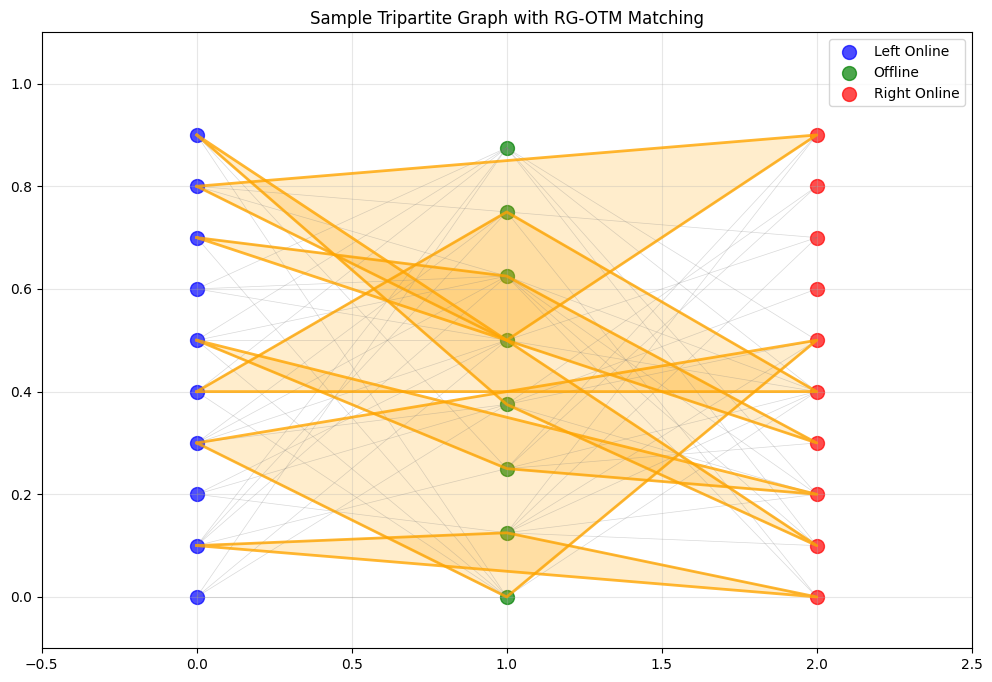


4. Running density experiment...


Testing densities: 100%|██████████| 8/8 [00:00<00:00, 37.04it/s]


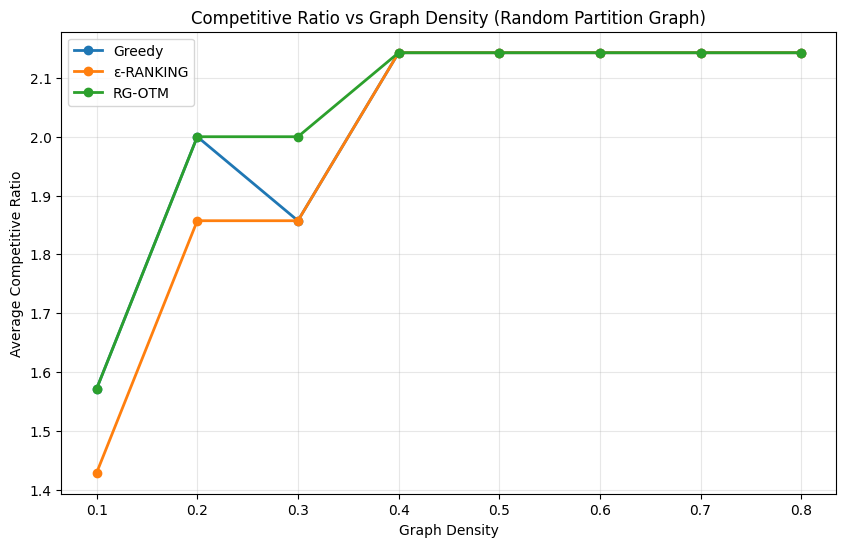


5. Running iteration experiment...


Testing on synthetic_random: 100%|██████████| 30/30 [00:00<00:00, 66.63it/s]


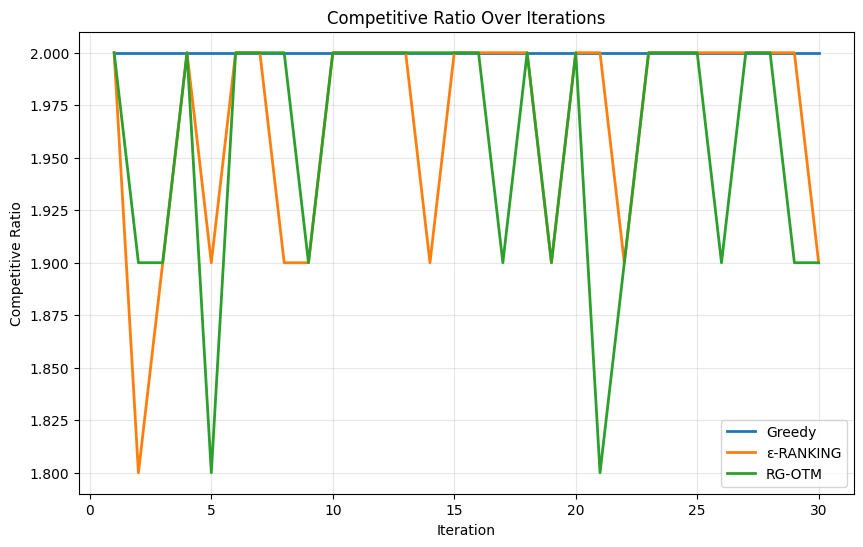


6. Creating interactive comparison...

7. Summary of results:
----------------------------------------
Greedy:
  Average Competitive Ratio: 2.0000
  Standard Deviation: 0.0000
  Min/Max: 2.0000/2.0000

ε-RANKING:
  Average Competitive Ratio: 1.9667
  Standard Deviation: 0.0537
  Min/Max: 1.8000/2.0000

RG-OTM:
  Average Competitive Ratio: 1.9567
  Standard Deviation: 0.0616
  Min/Max: 1.8000/2.0000

8. Comparing RG-OTM with and without RL...


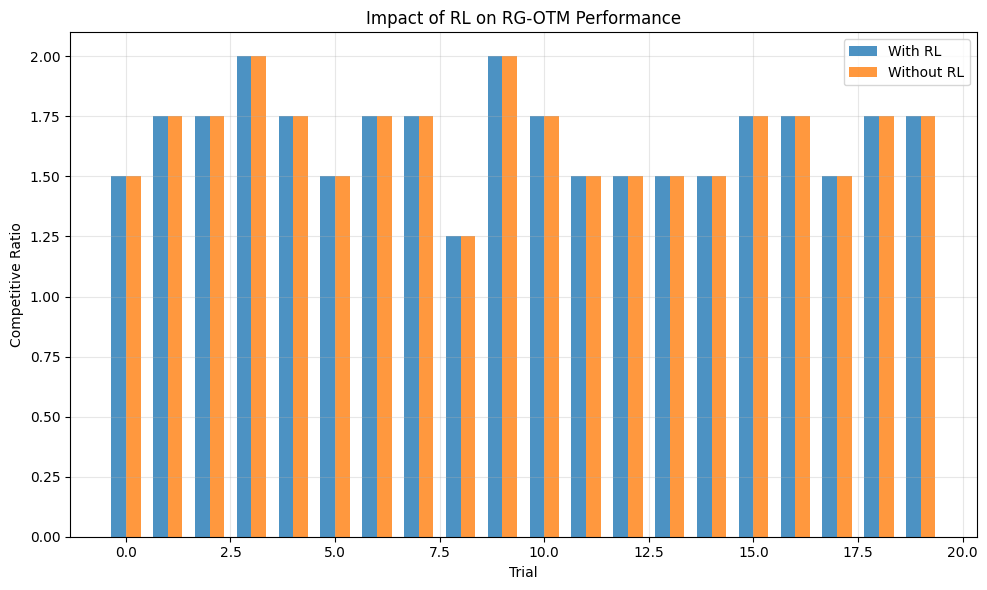


Experiment completed successfully!

🚀 Benchmarking Algorithms...

📈 Testing on Random Partition graph (density: 0.3)...

📈 Testing on Small World graph (density: 0.3)...

📈 Testing on Dense graph (density: 0.7)...

📈 Testing on Sparse graph (density: 0.1)...

Graph Type           Greedy          ε-RANKING       RG-OTM          Advanced RG-OTM
--------------------------------------------------------------------------------
Random Partition     15.0 ± 0.00     14.2 ± 0.40     14.2 ± 0.40     14.4 ± 0.49    
Small World          15.0 ± 0.00     14.8 ± 0.40     14.4 ± 0.80     14.8 ± 0.40    
Dense                15.0 ± 0.00     15.0 ± 0.00     15.0 ± 0.00     14.8 ± 0.40    
Sparse               12.8 ± 0.75     11.4 ± 0.49     9.6 ± 1.85      9.8 ± 1.17     


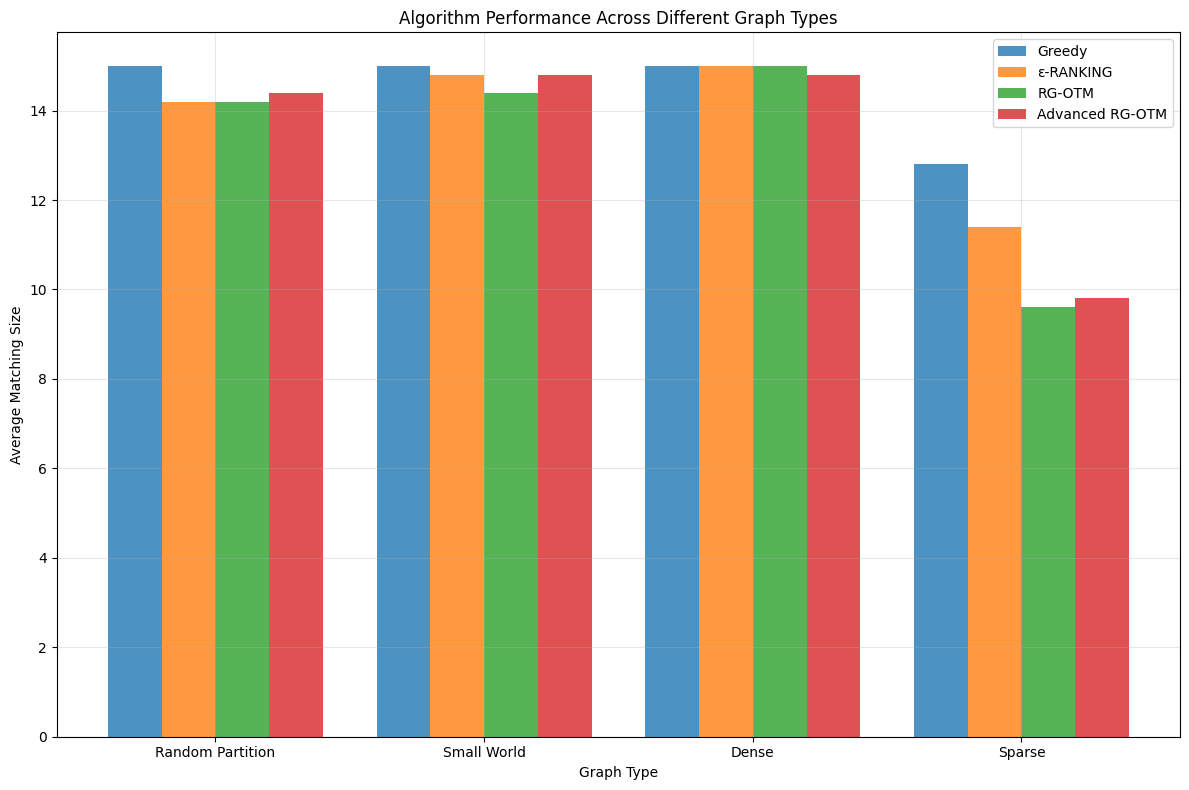


Pipeline execution completed successfully!


In [42]:
print("Starting RG-OTM Pipeline...")

# Run comprehensive experiment
results = run_comprehensive_experiment()

# Run benchmarking
benchmark_algorithms()

print("\n" + "=" * 60)
print("Pipeline execution completed successfully!")
print("=" * 60)